In [1]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt
from tensorflow.keras import models,layers

In [2]:
import os 
print(os.getcwd())
print(os.listdir())

C:\Users\LOQ\Deep project
['.ipynb_checkpoints', 'PlantVillage', 'Untitled.ipynb', 'Untitled1.ipynb']


In [3]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    batch_size=32,
    class_names=["Potato___healthy",'Potato___Late_blight','Potato___Early_blight'],
    image_size=(256,256)                          
                                                   )

Found 2152 files belonging to 3 classes.


In [4]:
class_names=dataset.class_names
class_names

['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']

In [5]:
len(dataset)

68

In [6]:
68*32

2176

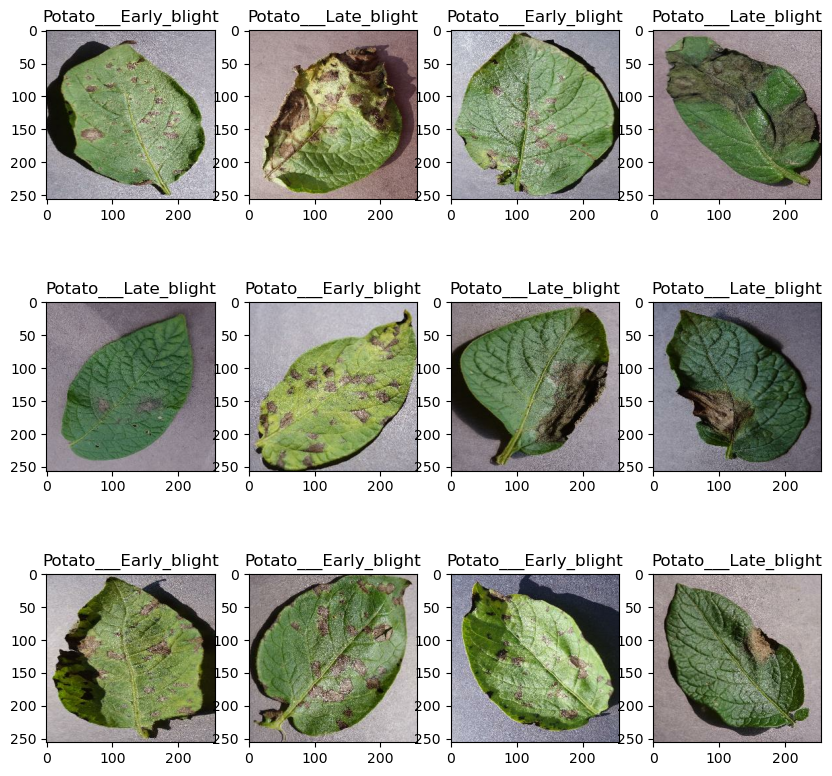

In [7]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    #print(image_batch.shape)
    #print(label_batch.numpy())
    #print(image_batch[0].numpy())
    for i in range(12):
       ax =plt.subplot(3,4,i+1)
       plt.imshow(image_batch[i].numpy().astype("uint8"))
       plt.title(class_names[label_batch[i]])

In [8]:
len(dataset)
train_size=.8
len(dataset)*train_size

54.400000000000006

In [9]:
train_ds=dataset.take(54)
len(train_ds)
test_ds=dataset.skip(54)
len(test_ds)

14

In [10]:
val_size=.1
len(dataset)*val_size

6.800000000000001

In [11]:
test_ds=test_ds.skip(6)
len(test_ds)

8

In [12]:
def get_dataset_partitions(ds,train_split=.8,test_split=.1,val_split=.1,shuffle=True):
    ds_size=len(ds)
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)
    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)
    return train_ds,val_ds,test_ds
    

In [13]:
train_ds,val_ds,test_ds=get_dataset_partitions(dataset)
len(train_ds)

54

In [14]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [15]:
IMAGE_SIZE=256

In [16]:
resize_and_rescale=tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    tf.keras.layers.Rescaling(1.0/255)
    
])

In [17]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(.2)
])

In [18]:
input_shape=(256,256,3)
model=models.Sequential([
    layers.Input(shape=input_shape),
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(3,activation="softmax")

    
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,891 (1.06 MB)

 Trainable params: 277,891 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [20]:
model.fit(train_ds,epochs=50,validation_data=val_ds,verbose=1)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 810ms/step - accuracy: 0.5278 - loss: 0.8765 - val_accuracy: 0.7240 - val_loss: 0.6695
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 44s 810ms/step - accuracy: 0.7841 - loss: 0.5392 - val_accuracy: 0.7500 - val_loss: 0.7059
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 44s 814ms/step - accuracy: 0.8426 - loss: 0.3553 - val_accuracy: 0.8229 - val_loss: 0.3453
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 801ms/step - accuracy: 0.8773 - loss: 0.3035 - val_accuracy: 0.8958 - val_loss: 0.2463
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 802ms/step - accuracy: 0.9184 - loss: 0.1998 - val_accuracy: 0.9219 - val_loss: 0.1797
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 806ms/step - accuracy: 0.9288 - loss: 0.1808 - val_accuracy: 0.9479 - val_loss: 0.1558
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 810ms/step - accuracy: 0.9520 - loss: 0.1263 - val_accuracy: 0.9635 - val_loss: 0.1004
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 44s 809ms/step - accuracy: 0.9578 - loss: 0.1327 - val_accu

In [23]:
scores=model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 194ms/step - accuracy: 1.0000 - loss: 0.0060


In [24]:
scores

[0.005998596083372831, 1.0]

In [25]:
%history

import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt
from tensorflow.keras import models,layers
import os 
print(os.getcwd())
print(os.listdir())
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    batch_size=32,
    class_names=["Potato___healthy",'Potato___Late_blight','Potato___Early_blight'],
    image_size=(256,256)                          
                                                   )
class_names=dataset.class_names
class_names
len(dataset)
68*32
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    #print(image_batch.shape)
    #print(label_batch.numpy())
    #print(image_batch[0].numpy())
    for i in range(12):
       ax =plt.subplot(3,4,i+1)
       plt.imshow(image_batch[i].numpy().astype("uint8"))
       plt.title(class_names[label_batch[i]])
len(dataset)
train_size=.8
len(dataset)*train_size
train_ds=dataset.take(54)
len(train_ds)
test_ds=dataset.skip(54)
len(test_ds

first image to predict 
first image actual label Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
predicted label : Potato___Late_blight


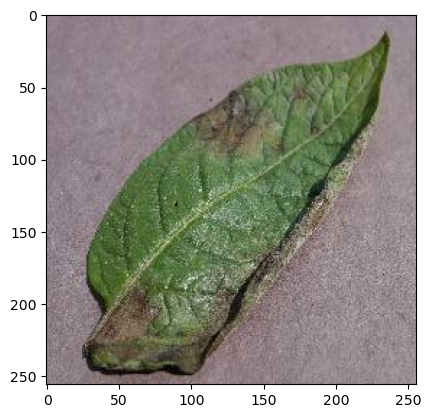

In [35]:
for images_batch,labels_batch in test_ds.take(1):
    first_image=images_batch[0].numpy().astype("uint8")
    first_label=labels_batch[0].numpy()
    print("first image to predict ")
    plt.imshow(first_image)
    print("first image actual label",class_names[first_label])
    batch_prediction=model.predict(images_batch)
    print("predicted label :",class_names[np.argmax(batch_prediction[0])])

In [36]:
def predict (model,img):
    img_array=tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array=tf.expand_dims(img_array,0)
    predictions=model.predict(img_array)
    predicted_class=class_names[np.argmax(predictions[0])]
    confidence=round(100*(np.max(predictions[0])),2)
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


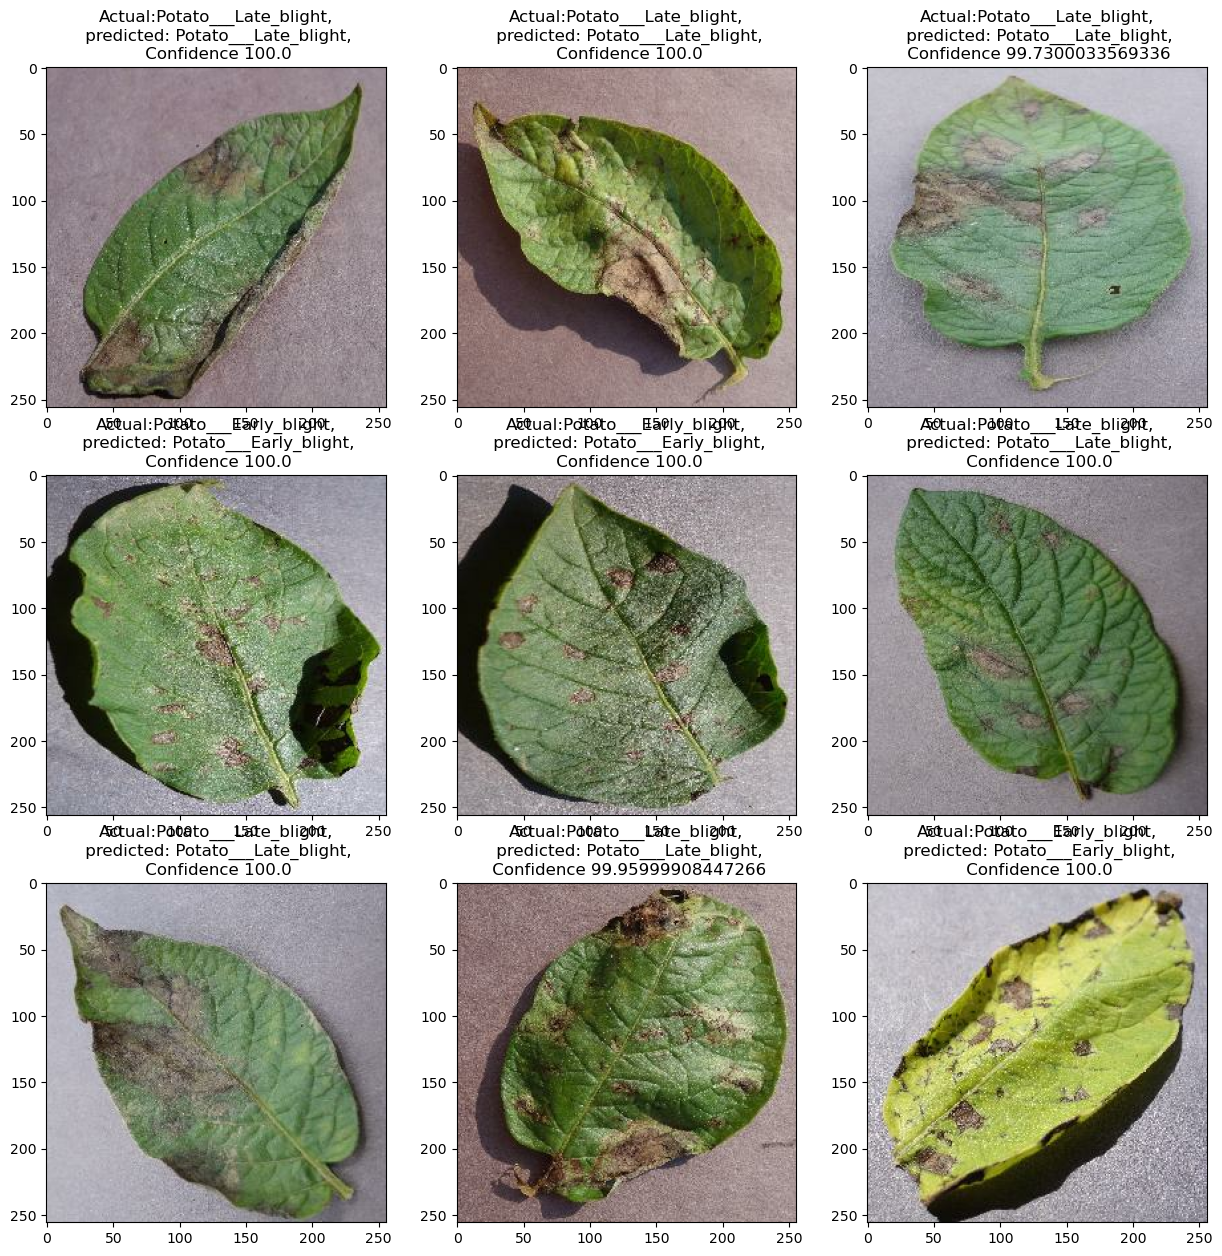

In [45]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        predicted_class,confidence=predict(model,images[i].numpy())
        actual_class=class_names[labels[i]]
        plt.title(f"Actual:{actual_class},\n predicted: {predicted_class},\n Confidence {confidence}")

In [52]:
model_version=1
model.save(f"../models/{model_version}.keras")

In [53]:
model.export(f"../models/{model_version}")

INFO:tensorflow:Assets written to: ../models/1\assets


INFO:tensorflow:Assets written to: ../models/1\assets


Saved artifact at '../models/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2563278728336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2563278721232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2563278717008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2563278731408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2563278731024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2563278731216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2563278730256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2563278731792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2563278731600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2563278732176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2563278732752: TensorSpec(shape=(), dty